In [1]:
import pandas as pd
df = pd.read_csv("iris.csv")
print(df.head())

# Central Tendency
print("Mean:\n", df.mean(numeric_only=True))
print("Median:\n", df.median(numeric_only=True))
print("Mode:\n", df.mode().iloc[0])

# Dispersion
print("Range:\n", df.max(numeric_only=True) - df.min(numeric_only=True))
print("Variance:\n", df.var(numeric_only=True))
print("Standard Deviation:\n", df.std(numeric_only=True))
print("IQR:\n", df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True))

# Shape

print("Skewness:\n", df.skew(numeric_only=True))
print("Kurtosis:\n", df.kurt(numeric_only=True))

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Mean:
 Id               75.500000
SepalLengthCm     5.843333
SepalWidthCm      3.054000
PetalLengthCm     3.758667
PetalWidthCm      1.198667
dtype: float64
Median:
 Id               75.50
SepalLengthCm     5.80
SepalWidthCm      3.00
PetalLengthCm     4.35
PetalWidthCm      1.30
dtype: float64
Mode:
 Id                         1
SepalLengthCm            5.0
SepalWidthCm             3.0
PetalLengthCm            1.5
PetalWidthCm             0.2
Species          Iris-setosa
Name: 0, dtype: object
Range:
 Id               149.0
SepalLe

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


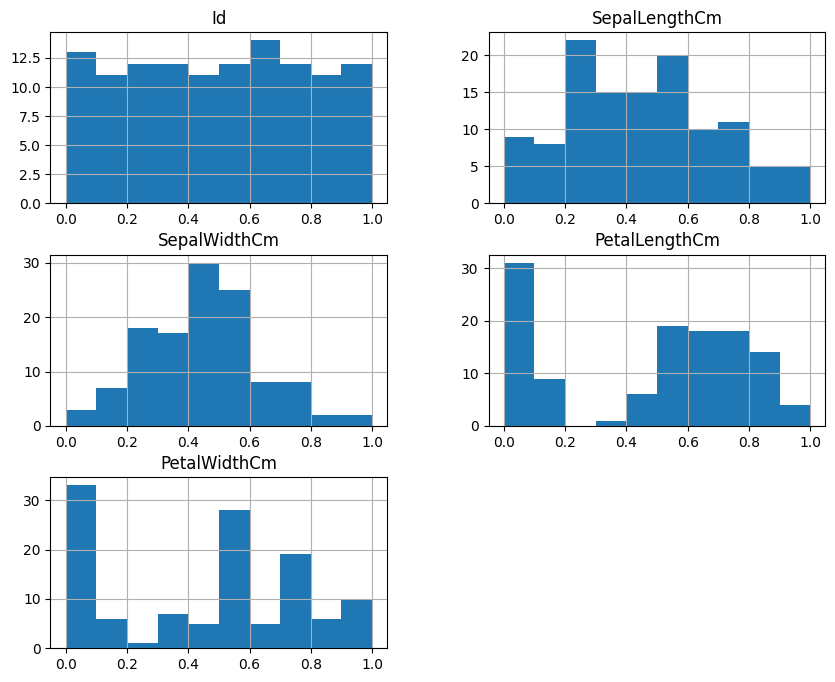

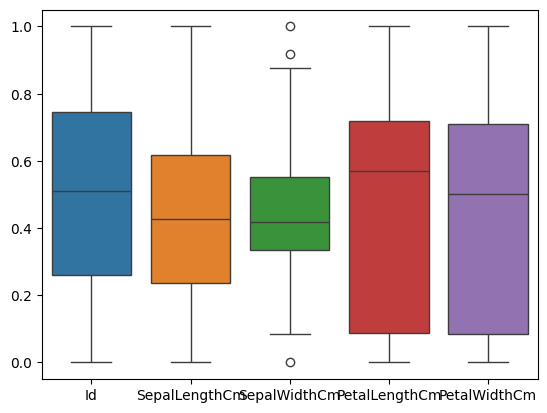

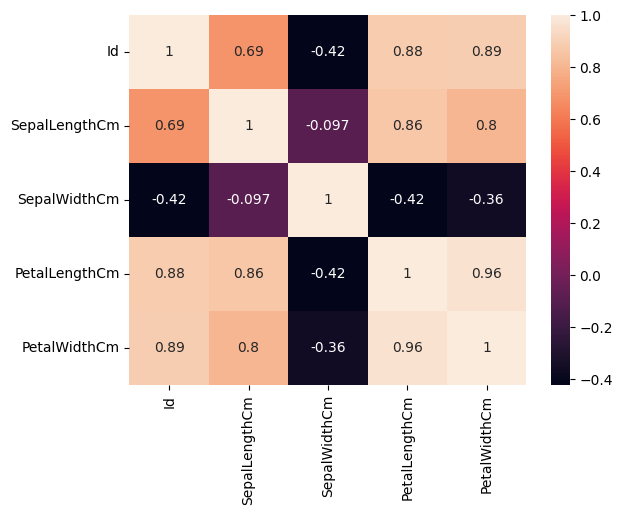

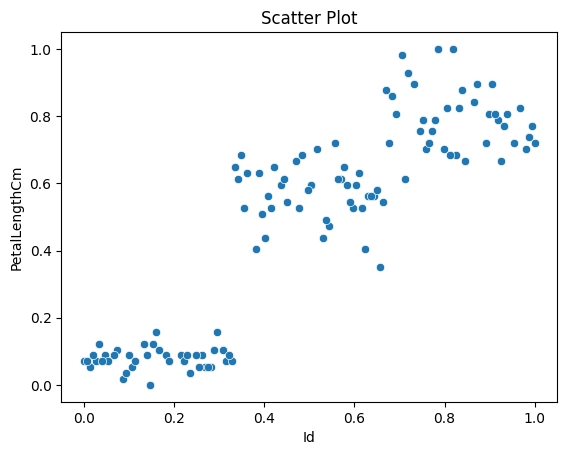

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
# Handle missing values
print(df.isnull().sum())
df = df.fillna(df.mean(numeric_only=True))

# Handle Label Encoding (Manually,if needed)
le=LabelEncoder()
df["Species"] =le.fit_transform(df["Species"])
# -------------------------------
# SPLITTING (Assuming last column is target)
# -------------------------------
X = df.drop("Species",axis=1)   # features
y = df["Species"]  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# DO EITHER NORMALIZATION OR STANDARDIZATION (ONLY ON TRAIN)
# -------------------------------
# NORMALIZATION (ONLY on TRAIN)
# -------------------------------
cat_cols=['Species'] # categorical columns
num_cols = X_train.select_dtypes(include='number').columns.difference(cat_cols)  # numeric cols

minmax = MinMaxScaler()
X_train[num_cols] = minmax.fit_transform(X_train[num_cols])
X_test[num_cols] = minmax.transform(X_test[num_cols])

# -------------------------------
# STANDARDIZATION (ONLY on TRAIN)
# -------------------------------
#scaler = StandardScaler()
#X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
#X_test[num_cols] = scaler.transform(X_test[num_cols])

# 5. Handle imbalance (only on training data ⚠️)

#smote = SMOTE()
#X_train, y_train = smote.fit_resample(X_train, y_train)
# -------------------------------
# VISUALIZATION (use full dataset OR train set)
# -------------------------------

# Histogram
X_train.hist(figsize=(10,8))
plt.show()

# Boxplot
sns.boxplot(data=X_train)
plt.show()

# Heatmap
sns.heatmap(X_train.corr(numeric_only=True), annot=True)
plt.show()

# Scatter Plot
if len(num_cols) >= 2:
    sns.scatterplot(x=X_train[num_cols[0]], y=X_train[num_cols[1]])
    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.title("Scatter Plot")
    plt.show()
else:
    print("Not enough numeric columns for scatter plot")


Covariance Matrix:
                      Id  PetalLengthCm  PetalWidthCm  SepalLengthCm  \
Id             0.084707       0.078673      0.081084       0.048514   
PetalLengthCm  0.078673       0.094395      0.092829       0.064183   
PetalWidthCm   0.081084       0.092829      0.098555       0.060965   
SepalLengthCm  0.048514       0.064183      0.060965       0.058707   
SepalWidthCm  -0.022795      -0.024141     -0.020891      -0.004380   

               SepalWidthCm  
Id                -0.022795  
PetalLengthCm     -0.024141  
PetalWidthCm      -0.020891  
SepalLengthCm     -0.004380  
SepalWidthCm       0.034596  

Correlation Matrix:
                      Id  PetalLengthCm  PetalWidthCm  SepalLengthCm  \
Id             1.000000       0.879816      0.887430       0.687962   
PetalLengthCm  0.879816       1.000000      0.962432       0.862183   
PetalWidthCm   0.887430       0.962432      1.000000       0.801485   
SepalLengthCm  0.687962       0.862183      0.801485       1.00000

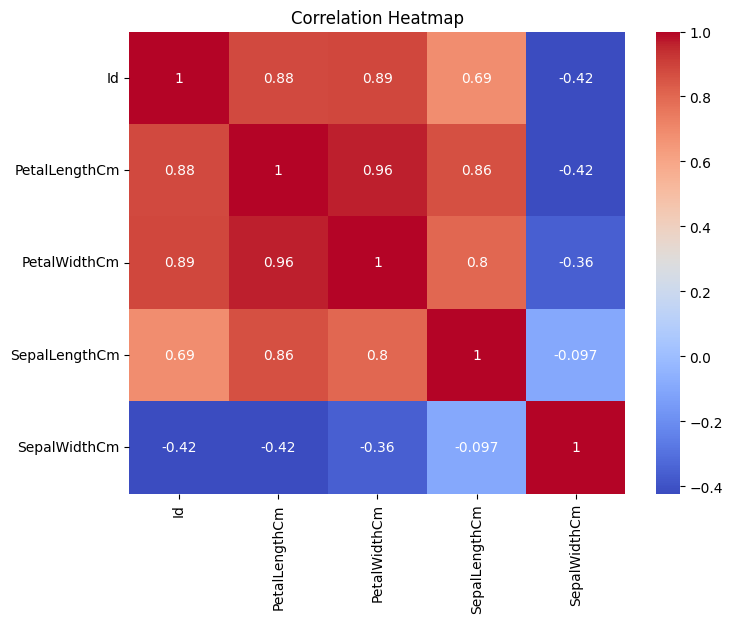

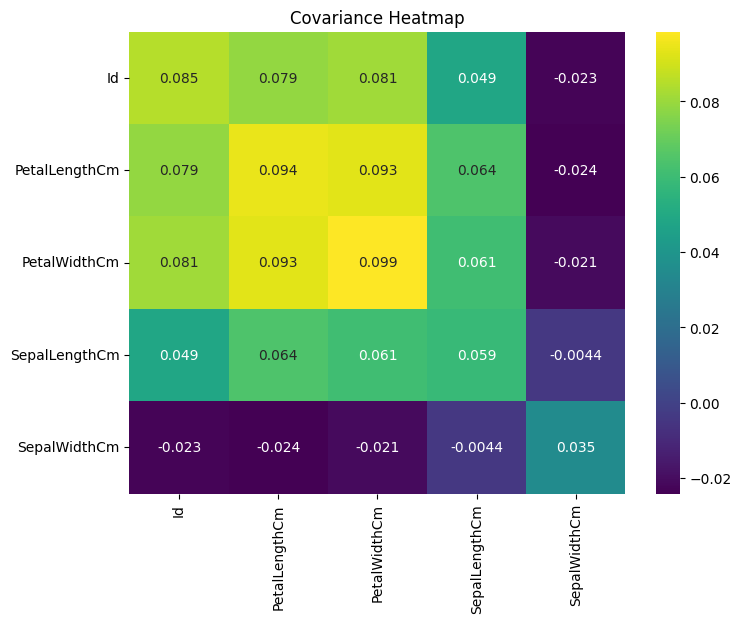

In [4]:
cov_matrix = X_train[num_cols].cov()
print("\nCovariance Matrix:\n", cov_matrix)

# -------------------------------
# CORRELATION
# -------------------------------
corr_matrix = X_train[num_cols].corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# -------------------------------
# HEATMAP FOR CORRELATION
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# HEATMAP FOR COVARIANCE
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(cov_matrix, annot=True, cmap='viridis')
plt.title("Covariance Heatmap")
plt.show()

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


--- Logistic Regression ---
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Cluster Labels:
 [2 2 2 2 2 2 2 2 2 2]


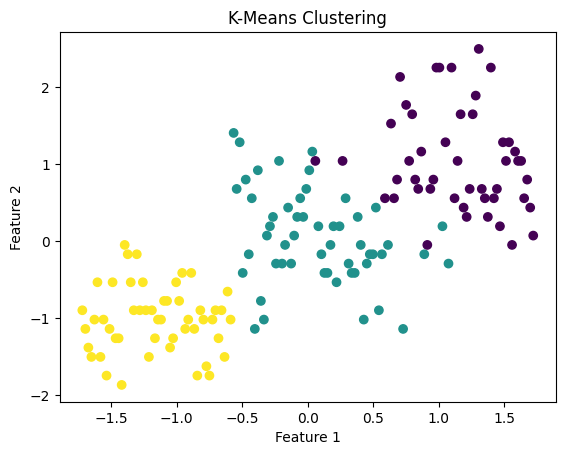

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("iris.csv")

# -------------------------------
# PREPROCESSING
# -------------------------------

# Handle missing values (numeric only)
df = df.fillna(df.mean(numeric_only=True))

# Keep only numerical columns
df_num = df.select_dtypes(include='number')

# -------------------------------
# SCALING (VERY IMPORTANT)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# -------------------------------
# FIND OPTIMAL K (ELBOW METHOD)
# -------------------------------
'''wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()'''

# -------------------------------
# APPLY K-MEANS (choose K=3 or from elbow)
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

print("Cluster Labels:\n", labels[:10])

# -------------------------------
# VISUALIZATION
# -------------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()